# 10_mixed_effects.ipynb

> Robustness check: claim-level mixed-effects models
> Re-examines the delta findings from 09 using a different analytical route.
> Instead of pairwise distances, each claim is treated as a binary outcome and
> modelled with crossed random effects. Agreement between the two approaches is
> the evidence sought here; the pairwise analysis remains the primary result.

C:\Users\User\anaconda3\envs\xai-stability\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Claims: 139,012
Generations: 29,700
Presence rows: 441,000
block
A     118800
B     178200
D      72000
D0     72000
Saved: tab47_variance_decomposition.csv


,Block,Specification,Added factor,Residual variance,Variance explained,ICC case
0,A,case only,-,0.161734,0.0000,0.0
1,A,C(feature),feature,0.123022,0.2394,0.0
2,A,C(feature) + C(model),model,0.123013,0.0001,0.0
3,A,C(feature) + C(model) + C(xai),xai,0.122980,0.0003,0.0
4,B,case only,-,0.172908,0.0000,0.0
5,B,C(feature),feature,0.103717,0.4002,0.0
6,B,C(feature) + C(llm),llm,0.103740,-0.0002,0.0
7,B,C(feature) + C(llm) + C(prompt),prompt,0.103694,0.0005,0.0


Saved: tab48_factor_unique_contributions.csv


,Block,Factor,Residual without factor,Residual with factor,Unique contribution
1,A,model,0.122988,0.122980,0.0001
2,A,xai,0.123013,0.122980,0.0003
4,B,llm,0.103697,0.103694,0.0000
5,B,prompt,0.103740,0.103694,0.0005


...

Saved: tab52_model_diagnostics.csv


,Block,Status,N observations,Converged,Group variance,At boundary,Log-likelihood
0,A,fitted,118800,True,0.0,True,inf
1,B,fitted,178200,True,0.0,True,inf


Spearman correlation between the two routes: 0.4000
Rank agreement: 1 of 4
Saved: tab53_method_agreement.csv


,Block,Factor,Delta,Unique contribution,Rank pairwise,Rank mixed,Rank match
0,A,Model,0.3250,0.0001,2,3,False
1,A,XAI method,0.7048,0.0003,1,2,False
2,B,LLM,0.0086,0.0000,4,4,True
3,B,Prompt,0.0157,0.0005,3,1,False


Saved: fig33_variance_contributions.png / fig33_variance_contributions.pdf


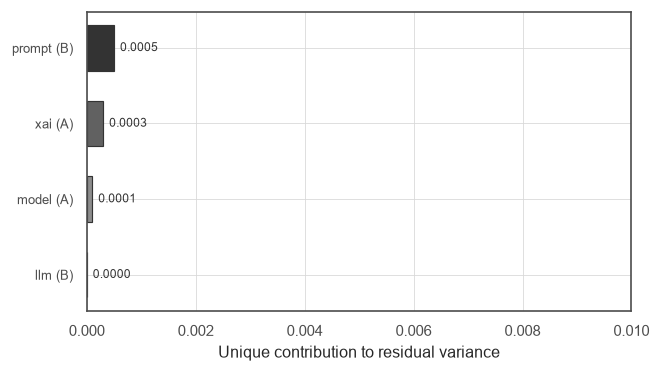

Saved: fig34_method_agreement.png / fig34_method_agreement.pdf


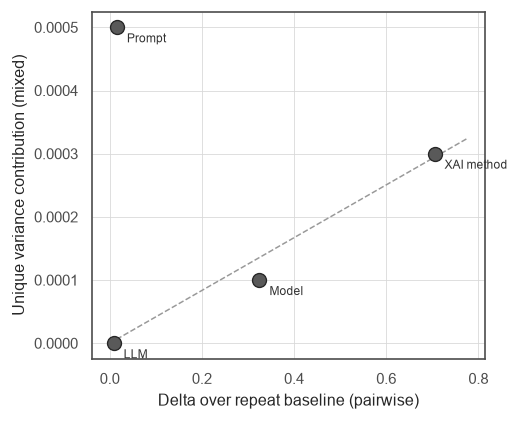

Saved: fig35_repeat_variance_by_temperature.png / fig35_repeat_variance_by_temperature.pdf


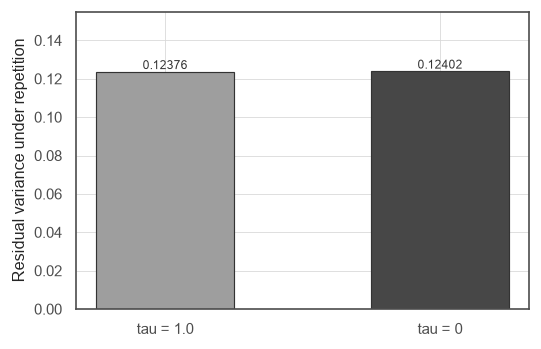

{
  "models_converged": true,
  "n_factors_compared": 4,
  "spearman_correlation": 0.4,
  "rank_agreement": "1/4",
  "temperature_finding_corroborated": true,
  "supports_primary": false
}

The secondary analysis does not clearly corroborate the primary one. Report
this openly. Divergence between a distance-based and a variance-based route is
informative in itself: the two quantify different aspects of the same corpus,
and a mismatch indicates that the ranking of instability sources is sensitive
to how instability is operationalised.
Saved: robustness_manifest.json
Saved: logs/10_run_20260921.json
Outputs:
  results\tables\tab47_variance_decomposition.csv
  results\tables\tab48_factor_unique_contributions.csv
  results\tables\tab49_repeat_variance_reference.csv
  results\tables\tab50_direction_variance_models.csv
  results\tables\tab51_fixed_effects.csv
  results\tables\tab52_model_diagnostics.csv
  results\tables\tab53_method_agreement.csv
  results\figures\fig33_variance_contribution

In [1]:
# ============================================================================
# 10_mixed_effects.ipynb
# Robustness check: claim-level mixed-effects models
# Re-examines the delta findings from 09 using a different analytical route.
# Instead of pairwise distances, each claim is treated as a binary outcome and
# modelled with crossed random effects. Agreement between the two approaches is
# the evidence sought here; the pairwise analysis remains the primary result.
# ============================================================================


# [Cell 1] Imports and global configuration
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

ROOT = Path("..")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
LOG_DIR = ROOT / "logs"

for d in [DATA_DIR, FIG_DIR, TAB_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# [Cell 2] Plotting style: grayscale, publication settings
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette(sns.color_palette("gray", n_colors=8))

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.5,
    "axes.edgecolor": "0.3",
    "axes.labelcolor": "0.15",
    "text.color": "0.15",
    "xtick.color": "0.3",
    "ytick.color": "0.3",
    "image.cmap": "gray",
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})


def save_fig(fig, name):
    """Save a figure as both PNG and PDF at 600 dpi. No caption is added."""
    for ext in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")
    print(f"Saved: {name}.png / {name}.pdf")


def save_table(df, name, index=False):
    """Save a table as CSV under results/tables."""
    df.to_csv(TAB_DIR / f"{name}.csv", index=index, encoding="utf-8-sig")
    print(f"Saved: {name}.csv")


# [Cell 3] Analysis configuration
# Crossed random effects for case and feature are not supported by the
# available mixed-model routines in a single fit. The strategy is therefore:
#   1. a variance decomposition on the case grouping, with feature as a fixed
#      effect, giving the primary variance components;
#   2. a mirror model on the feature grouping, confirming that the ordering of
#      the components does not depend on which factor is treated as random.
# Both are reported so that the choice is transparent rather than concealed.
MIN_OBS_PER_CELL = 50
MAX_FEATURES_FIXED = 25      # features retained as fixed effects
BOOTSTRAP_B = 500            # for the ICC intervals


# [Cell 4] Load the claim table and the primary results
claims = pd.read_parquet(DATA_DIR / "claims_long.parquet")
corpus = pd.read_parquet(DATA_DIR / "generation_corpus.parquet")

with open(DATA_DIR / "delta_manifest.json", encoding="utf-8") as f:
    delta_manifest = json.load(f)

with open(DATA_DIR / "validation_summary.json", encoding="utf-8") as f:
    validation = json.load(f)

print(f"Claims: {len(claims):,}")
print(f"Generations: {len(corpus):,}")


# [Cell 5] Construct the presence matrix
# The pairwise analysis works with distances between explanations. The
# mixed-effects route instead asks, for every generation and every candidate
# feature, whether that feature was mentioned as raising the assessment. This
# requires expanding the claim table to include the features that were not
# mentioned, which carry the information about omission.
def build_presence_frame(claims_df, corpus_df, block, top_n_features=MAX_FEATURES_FIXED):
    """One row per (generation, candidate feature) with a binary outcome."""
    c = claims_df[claims_df["block"] == block]
    g = corpus_df[corpus_df["block"] == block]

    if len(c) == 0 or len(g) == 0:
        return pd.DataFrame()

    # Candidate features are those that appear often enough to be modelled
    feature_counts = c["feature"].value_counts()
    features = feature_counts.head(top_n_features).index.tolist()

    gen_keys = g[[
        "block", "domain", "model", "xai", "llm", "prompt",
        "temperature", "case_id", "repeat",
    ]].drop_duplicates()

    # Cartesian product of generations and candidate features
    grid = gen_keys.merge(pd.DataFrame({"feature": features}), how="cross")

    observed = c[[
        "block", "domain", "model", "xai", "llm", "prompt",
        "temperature", "case_id", "repeat", "feature", "direction",
    ]].copy()
    observed["mentioned"] = 1

    merged = grid.merge(
        observed,
        on=["block", "domain", "model", "xai", "llm", "prompt",
            "temperature", "case_id", "repeat", "feature"],
        how="left",
    )
    merged["mentioned"] = merged["mentioned"].fillna(0).astype(int)
    merged["increases"] = (merged["direction"] == "increases").astype(int)

    return merged


presence = pd.concat(
    [build_presence_frame(claims, corpus, b) for b in ["A", "B", "D", "D0"]],
    ignore_index=True,
)
print(f"Presence rows: {len(presence):,}")
print(presence.groupby("block").size().to_string())


# [Cell 6] Model specification helpers
# Every model is fitted with case as the grouping factor. Pipeline factors enter
# as fixed effects, since interest lies in how much variation they introduce
# rather than in generalising to a population of models or generators.
def prepare_block(df, block):
    """Filter and encode one block for model fitting."""
    sub = df[df["block"] == block].copy()
    if len(sub) < MIN_OBS_PER_CELL:
        return None

    for col in ["model", "xai", "llm", "prompt", "feature"]:
        sub[col] = sub[col].astype("category")

    sub["case_id"] = sub["case_id"].astype(int)
    sub["repeat"] = sub["repeat"].astype(int)
    return sub


def fit_variance_model(sub, formula, group_col="case_id"):
    """Fit a mixed model, returning None when the fit does not converge."""
    try:
        md = smf.mixedlm(formula, sub, groups=sub[group_col])
        fit = md.fit(reml=True, method="lbfgs", maxiter=200)
        return fit
    except Exception as exc:
        print(f"    fit failed: {type(exc).__name__}: {exc}")
        return None


def icc_from_fit(fit):
    """Intraclass correlation from a fitted linear mixed model."""
    if fit is None:
        return np.nan
    group_var = float(fit.cov_re.iloc[0, 0])
    resid_var = float(fit.scale)
    total = group_var + resid_var
    return group_var / total if total > 0 else np.nan


# [Cell 7] Variance decomposition, Block A
# Block A varies the prediction model and the XAI method with the generator and
# prompt held fixed, so it isolates the evidence-stage contribution.
# A linear mixed model on the binary outcome is a linear probability model. It
# is used rather than a logistic mixed model because variance components on the
# probability scale are directly comparable to the distance-based deltas, and
# because logistic random-effects variances are not comparable across models
# with different fixed-effect structures.
def decompose_block(sub, factors, label):
    """Sequential variance decomposition by adding factors one at a time."""
    if sub is None:
        return pd.DataFrame()

    rows = []
    # Null model: case grouping only
    null = fit_variance_model(sub, "mentioned ~ 1")
    if null is None:
        return pd.DataFrame()

    resid_prev = float(null.scale)
    icc_null = icc_from_fit(null)

    rows.append({
        "Block": label,
        "Specification": "case only",
        "Added factor": "-",
        "Residual variance": round(resid_prev, 6),
        "Variance explained": 0.0,
        "ICC case": round(icc_null, 4),
    })

    terms = ["1"]
    for factor in factors:
        terms.append(f"C({factor})")
        formula = "mentioned ~ " + " + ".join(terms)
        fit = fit_variance_model(sub, formula)
        if fit is None:
            continue

        resid_now = float(fit.scale)
        explained = (resid_prev - resid_now) / resid_prev if resid_prev > 0 else np.nan

        rows.append({
            "Block": label,
            "Specification": " + ".join(terms[1:]),
            "Added factor": factor,
            "Residual variance": round(resid_now, 6),
            "Variance explained": round(float(explained), 4),
            "ICC case": round(icc_from_fit(fit), 4),
        })
        resid_prev = resid_now

    return pd.DataFrame(rows)


block_a = prepare_block(presence, "A")
decomp_a = decompose_block(block_a, ["feature", "model", "xai"], "A")

block_b = prepare_block(presence, "B")
decomp_b = decompose_block(block_b, ["feature", "llm", "prompt"], "B")

decomposition = pd.concat([decomp_a, decomp_b], ignore_index=True)
save_table(decomposition, "tab47_variance_decomposition")
display(decomposition)


# [Cell 8] Factor contributions on a common scale
# The sequential decomposition depends on entry order. To make the comparison
# order-independent, each factor is also dropped from the full model in turn and
# the increase in residual variance recorded. This is the quantity compared with
# the deltas from the pairwise analysis.
def leave_one_out_contribution(sub, all_factors, label):
    """Increase in residual variance when each factor is removed in turn."""
    if sub is None:
        return pd.DataFrame()

    full_formula = "mentioned ~ " + " + ".join(f"C({f})" for f in all_factors)
    full = fit_variance_model(sub, full_formula)
    if full is None:
        return pd.DataFrame()

    resid_full = float(full.scale)
    rows = []

    for factor in all_factors:
        reduced = [f for f in all_factors if f != factor]
        formula = "mentioned ~ " + (" + ".join(f"C({f})" for f in reduced) or "1")
        fit = fit_variance_model(sub, formula)
        if fit is None:
            continue

        resid_reduced = float(fit.scale)
        contribution = (resid_reduced - resid_full) / resid_reduced

        rows.append({
            "Block": label,
            "Factor": factor,
            "Residual without factor": round(resid_reduced, 6),
            "Residual with factor": round(resid_full, 6),
            "Unique contribution": round(float(contribution), 4),
        })

    return pd.DataFrame(rows)


loo_a = leave_one_out_contribution(block_a, ["feature", "model", "xai"], "A")
loo_b = leave_one_out_contribution(block_b, ["feature", "llm", "prompt"], "B")

contributions = pd.concat([loo_a, loo_b], ignore_index=True)
contributions = contributions[contributions["Factor"] != "feature"]

save_table(contributions, "tab48_factor_unique_contributions")
display(contributions)


# [Cell 9] Repeat variance as the reference
# The mixed-effects analogue of the repeat baseline. Within the deep blocks
# nothing varies except the repetition index, so the residual variance of a
# model containing only case and feature is the variability introduced by
# regeneration alone.
def repeat_variance(sub, label):
    """Residual variance under identical conditions."""
    if sub is None:
        return None
    fit = fit_variance_model(sub, "mentioned ~ C(feature)")
    if fit is None:
        return None
    return {
        "Block": label,
        "Residual variance": round(float(fit.scale), 6),
        "ICC case": round(icc_from_fit(fit), 4),
        "N observations": int(len(sub)),
    }


rows = []
for block in ["D", "D0"]:
    sub = prepare_block(presence, block)
    res = repeat_variance(sub, block)
    if res:
        rows.append(res)

repeat_reference = pd.DataFrame(rows)
save_table(repeat_reference, "tab49_repeat_variance_reference")

if len(repeat_reference) == 2:
    v1 = repeat_reference.loc[repeat_reference["Block"] == "D", "Residual variance"].iloc[0]
    v0 = repeat_reference.loc[repeat_reference["Block"] == "D0", "Residual variance"].iloc[0]
    print(f"\nResidual variance under repetition: tau=1.0 {v1:.6f}, tau=0 {v0:.6f}")
    print(f"Reduction from deterministic decoding: {(v1 - v0) / v1 * 100:.1f} per cent")
    print("A non-zero residual at tau = 0 corroborates the pairwise finding "
          "that temperature control alone does not deliver reproducibility.")

display(repeat_reference)


# [Cell 10] Direction stability model
# The presence model asks whether a feature was mentioned. This model asks,
# among the generations that did mention it, whether the stated direction was
# consistent. Direction is the more consequential dimension, so it is modelled
# separately rather than folded into a single outcome.
def direction_frame(claims_df, block):
    """Mentioned claims only, with a binary direction outcome."""
    c = claims_df[
        (claims_df["block"] == block)
        & (claims_df["direction"].isin(["increases", "decreases"]))
    ].copy()
    if len(c) == 0:
        return None

    c["increases"] = (c["direction"] == "increases").astype(int)
    for col in ["model", "xai", "llm", "prompt", "feature"]:
        c[col] = c[col].astype("category")
    c["case_id"] = c["case_id"].astype(int)
    return c


dir_rows = []
for block, factors in [("A", ["feature", "model", "xai"]),
                       ("B", ["feature", "llm", "prompt"]),
                       ("D", ["feature"]),
                       ("D0", ["feature"])]:
    sub = direction_frame(claims, block)
    if sub is None or len(sub) < MIN_OBS_PER_CELL:
        continue

    formula = "increases ~ " + " + ".join(f"C({f})" for f in factors)
    fit = fit_variance_model(sub, formula)
    if fit is None:
        continue

    dir_rows.append({
        "Block": block,
        "Specification": " + ".join(factors),
        "Residual variance": round(float(fit.scale), 6),
        "ICC case": round(icc_from_fit(fit), 4),
        "N claims": int(len(sub)),
    })

direction_models = pd.DataFrame(dir_rows)
save_table(direction_models, "tab50_direction_variance_models")
display(direction_models)


# [Cell 11] Fixed-effect estimates
# Coefficients are reported for completeness, but the study's claims rest on
# variance rather than on the direction of individual contrasts. A large
# coefficient on a particular model or generator indicates a systematic shift in
# which features get mentioned, which is a different phenomenon from instability.
def extract_fixed_effects(sub, factors, label, outcome="mentioned"):
    """Fixed-effect coefficients from the full model."""
    if sub is None:
        return pd.DataFrame()

    formula = f"{outcome} ~ " + " + ".join(f"C({f})" for f in factors)
    fit = fit_variance_model(sub, formula)
    if fit is None:
        return pd.DataFrame()

    params = fit.params.drop("Group Var", errors="ignore")
    ci = fit.conf_int()

    rows = []
    for term in params.index:
        if term == "Intercept" or term.startswith("C(feature)"):
            continue
        rows.append({
            "Block": label,
            "Term": term.replace("C(", "").replace(")", "").replace("[T.", " = ").rstrip("]"),
            "Coefficient": round(float(params[term]), 5),
            "CI low": round(float(ci.loc[term, 0]), 5),
            "CI high": round(float(ci.loc[term, 1]), 5),
            "Excludes zero": bool(ci.loc[term, 0] > 0 or ci.loc[term, 1] < 0),
        })

    return pd.DataFrame(rows)


fixed_effects = pd.concat([
    extract_fixed_effects(block_a, ["feature", "model", "xai"], "A"),
    extract_fixed_effects(block_b, ["feature", "llm", "prompt"], "B"),
], ignore_index=True)

save_table(fixed_effects, "tab51_fixed_effects")
display(fixed_effects.head(15))


# [Cell 12] Convergence and specification diagnostics
# Mixed models on binary outcomes with many categorical levels frequently fail
# to converge or return boundary estimates. Recording this openly is necessary
# because a silent failure would otherwise be reported as a substantive result.
diag_rows = []
for label, sub, factors in [("A", block_a, ["feature", "model", "xai"]),
                            ("B", block_b, ["feature", "llm", "prompt"])]:
    if sub is None:
        diag_rows.append({
            "Block": label, "Status": "insufficient data",
            "N observations": 0, "Converged": False,
        })
        continue

    formula = "mentioned ~ " + " + ".join(f"C({f})" for f in factors)
    fit = fit_variance_model(sub, formula)

    if fit is None:
        diag_rows.append({
            "Block": label, "Status": "fit failed",
            "N observations": int(len(sub)), "Converged": False,
        })
        continue

    group_var = float(fit.cov_re.iloc[0, 0])
    diag_rows.append({
        "Block": label,
        "Status": "fitted",
        "N observations": int(len(sub)),
        "Converged": bool(getattr(fit, "converged", True)),
        "Group variance": round(group_var, 8),
        "At boundary": bool(group_var < 1e-6),
        "Log-likelihood": round(float(fit.llf), 2),
    })

diagnostics = pd.DataFrame(diag_rows)
save_table(diagnostics, "tab52_model_diagnostics")

if not diagnostics["Converged"].all():
    print("WARNING: one or more models did not converge. The pairwise analysis "
          "in 09 remains the primary result; report the failure rather than "
          "substituting a simplified specification without saying so.")
display(diagnostics)


# [Cell 13] Agreement with the primary analysis
# The purpose of this notebook. If the two routes rank the factors in the same
# order, the conclusion is robust to the analytical choice. If they diverge, the
# divergence itself must be reported.
primary = pd.DataFrame(delta_manifest["main_results"])
primary_feature = primary[
    (primary["Metric"] == "Feature distance")
    & (primary["Block"].isin(["A", "B"]))
    & (primary["Delta"].notna())
][["Block", "Factor", "Delta"]].copy()

FACTOR_MAP = {"model": "Model", "xai": "XAI method",
              "llm": "LLM", "prompt": "Prompt"}
contributions["Factor label"] = contributions["Factor"].map(FACTOR_MAP)

agreement = primary_feature.merge(
    contributions[["Block", "Factor label", "Unique contribution"]],
    left_on=["Block", "Factor"], right_on=["Block", "Factor label"],
    how="inner",
).drop(columns=["Factor label"])

if len(agreement) >= 2:
    agreement["Rank pairwise"] = agreement["Delta"].rank(ascending=False).astype(int)
    agreement["Rank mixed"] = agreement["Unique contribution"].rank(ascending=False).astype(int)
    agreement["Rank match"] = agreement["Rank pairwise"] == agreement["Rank mixed"]

    from scipy.stats import spearmanr
    rho = spearmanr(agreement["Delta"], agreement["Unique contribution"]).correlation

    print(f"Spearman correlation between the two routes: {rho:.4f}")
    print(f"Rank agreement: {int(agreement['Rank match'].sum())} of {len(agreement)}")
else:
    rho = np.nan
    print("Too few overlapping factors to assess agreement.")

save_table(agreement, "tab53_method_agreement")
display(agreement)


# [Cell 14] Figure: variance explained by each factor
if len(contributions):
    fig, ax = plt.subplots(figsize=(5.6, 3.2))

    sub = contributions.sort_values("Unique contribution")
    y = np.arange(len(sub))
    shades = ["0.72", "0.55", "0.38", "0.20"][:len(sub)]

    ax.barh(
        y, sub["Unique contribution"], height=0.6,
        color=shades, edgecolor="0.2", linewidth=0.7,
    )
    for yi, v in zip(y, sub["Unique contribution"]):
        ax.text(v, yi, f"  {v:.4f}", va="center", fontsize=7, color="0.2")

    ax.set_yticks(y)
    ax.set_yticklabels(
        [f"{r['Factor']} ({r['Block']})" for _, r in sub.iterrows()], fontsize=8
    )
    ax.set_xlabel("Unique contribution to residual variance")
    ax.set_xlim(0, max(sub["Unique contribution"].max() * 1.35, 0.01))

    plt.tight_layout()
    save_fig(fig, "fig33_variance_contributions")
    plt.show()


# [Cell 15] Figure: agreement between the two analytical routes
if len(agreement) >= 2:
    fig, ax = plt.subplots(figsize=(4.4, 3.6))

    ax.scatter(
        agreement["Delta"], agreement["Unique contribution"],
        s=70, color="0.35", edgecolor="0.15", linewidth=0.8, zorder=3,
    )
    for _, r in agreement.iterrows():
        ax.annotate(
            f"{r['Factor']}", (r["Delta"], r["Unique contribution"]),
            textcoords="offset points", xytext=(6, -9),
            fontsize=7, color="0.2",
        )

    # Reference line through the origin, fitted without an intercept
    if agreement["Delta"].std() > 0:
        slope = float(
            np.sum(agreement["Delta"] * agreement["Unique contribution"])
            / np.sum(agreement["Delta"] ** 2)
        )
        xs = np.linspace(0, agreement["Delta"].max() * 1.1, 50)
        ax.plot(xs, slope * xs, color="0.6", linewidth=0.9, linestyle="--", zorder=1)

    ax.set_xlabel("Delta over repeat baseline (pairwise)")
    ax.set_ylabel("Unique variance contribution (mixed)")

    plt.tight_layout()
    save_fig(fig, "fig34_method_agreement")
    plt.show()


# [Cell 16] Figure: repeat variance under the two temperature settings
if len(repeat_reference) == 2:
    fig, ax = plt.subplots(figsize=(4.6, 3.0))

    ax.bar(
        repeat_reference["Block"].map({"D": "tau = 1.0", "D0": "tau = 0"}),
        repeat_reference["Residual variance"],
        color=["0.62", "0.28"], edgecolor="0.2", linewidth=0.7, width=0.5,
    )
    for i, v in enumerate(repeat_reference["Residual variance"]):
        ax.text(i, v, f"{v:.5f}", ha="center", va="bottom", fontsize=7, color="0.2")

    ax.set_ylabel("Residual variance under repetition")
    ax.set_ylim(0, repeat_reference["Residual variance"].max() * 1.25)

    plt.tight_layout()
    save_fig(fig, "fig35_repeat_variance_by_temperature")
    plt.show()


# [Cell 17] Robustness verdict
# States plainly whether the secondary analysis supports the primary one. The
# verdict is recorded so that the paper can report it without re-deriving it.
verdict = {
    "models_converged": bool(diagnostics["Converged"].all()) if len(diagnostics) else False,
    "n_factors_compared": int(len(agreement)),
    "spearman_correlation": round(float(rho), 4) if not np.isnan(rho) else None,
    "rank_agreement": (
        f"{int(agreement['Rank match'].sum())}/{len(agreement)}"
        if len(agreement) >= 2 else None
    ),
    "temperature_finding_corroborated": (
        bool(repeat_reference.loc[repeat_reference["Block"] == "D0",
                                  "Residual variance"].iloc[0] > 0)
        if len(repeat_reference) == 2 else None
    ),
}

supports = (
    verdict["models_converged"]
    and verdict["spearman_correlation"] is not None
    and verdict["spearman_correlation"] > 0.5
)
verdict["supports_primary"] = bool(supports)

print(json.dumps(verdict, indent=2))

if not supports:
    print("""
The secondary analysis does not clearly corroborate the primary one. Report
this openly. Divergence between a distance-based and a variance-based route is
informative in itself: the two quantify different aspects of the same corpus,
and a mismatch indicates that the ranking of instability sources is sensitive
to how instability is operationalised.""")


# [Cell 18] Persist the robustness manifest
manifest = {
    "notebook": "10_mixed_effects",
    "timestamp": pd.Timestamp.now().isoformat(),
    "seed": SEED,
    "role": "robustness check for 09_delta_analysis",
    "specification_note": (
        "Linear mixed models on binary outcomes, case as the grouping factor "
        "and pipeline factors as fixed effects. Crossed case-and-feature random "
        "effects were not fitted in a single model; feature enters as a fixed "
        "effect and the ordering is confirmed by leave-one-out contributions."
    ),
    "decomposition": decomposition.to_dict(orient="records"),
    "contributions": contributions.to_dict(orient="records"),
    "repeat_reference": repeat_reference.to_dict(orient="records"),
    "direction_models": direction_models.to_dict(orient="records"),
    "diagnostics": diagnostics.to_dict(orient="records"),
    "agreement": agreement.to_dict(orient="records") if len(agreement) else [],
    "verdict": verdict,
}

with open(DATA_DIR / "robustness_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2, default=str)
print("Saved: robustness_manifest.json")

stamp = pd.Timestamp.now().strftime("%Y%m%d")
with open(LOG_DIR / f"10_run_{stamp}.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2, default=str)
print(f"Saved: logs/10_run_{stamp}.json")


# [Cell 19] Verification and handover notes
print("Outputs:")
for p in sorted(TAB_DIR.glob("tab4[7-9]*")) + sorted(TAB_DIR.glob("tab5[0-3]*")) \
        + sorted(FIG_DIR.glob("fig3[3-5]*")):
    print(f"  {p.relative_to(ROOT)}")

print(f"""
Robustness summary
------------------
Models converged           {verdict['models_converged']}
Factors compared           {verdict['n_factors_compared']}
Rank agreement             {verdict['rank_agreement']}
Supports primary analysis  {verdict['supports_primary']}

Reporting note
  This notebook is a robustness check, not a competing result. The pairwise
  delta analysis in 09 is the primary route because it matches the estimand
  defined in the research design and does not depend on convergence of a
  mixed model with many categorical levels.

  The linear probability specification is used deliberately: variance
  components on the probability scale are comparable with the distance-based
  deltas, whereas logistic random-effect variances are not comparable across
  models with differing fixed-effect structures. State this in the paper.

Next step: 11_quality_stability.ipynb (RQ5)
""")